# BRACE-V5 — Benefit–Risk Aware Conditional Multimodal Escalation

This notebook is the **V5 research revision** of the CFUR/RACE multimodal fake-news detection pipeline.

## Scientific question

> Under a fixed additional-compute budget, can a cheap-side model identify samples that are both **at risk of a wrong cheap decision** and **likely to benefit from expensive multimodal reasoning**?

V4 showed that risk can concentrate cheap-model errors, but high-risk samples are not necessarily improved by the deep ViLT branch. V5 therefore combines a **risk model**, a **deep-benefit probability model**, and an **expected-gain regressor**.

### BRACE principle

We estimate, using leakage-safe out-of-sample targets:

1. `Risk(x) = P(cheap prediction is wrong | cheap-side features)`
2. `BenefitProb(x) = P(deep branch improves the cheap decision | cheap-side features)`
3. `ExpectedGain(x) = predicted CE reduction`

The inference score is:

`BRACE(x) = Risk(x) × BenefitProb(x) × max(ExpectedGain(x), 0)`

Only cheap-side features are used at inference; the ViLT branch is invoked **after** routing.

### Evaluation

- Frozen CLIP and ViLT backbones.
- Cheap classifier + residual deep correction head.
- Separate base / routing-fit / routing-calibration splits.
- Matched budgets: 0–100% deep execution.
- Baselines: CLIP-cheap, Always-deep, uncertainty, modality disagreement, random.
- Oracle upper bound is analysis-only and never used for model selection.
- Risk, benefit, calibration, bootstrap, and compute/latency diagnostics.


In [1]:
# Kaggle dependency setup
# Internet must be enabled for the first model download.
#
# Pillow ships quarterly and has twice broken this exact import chain:
#   ImportError: cannot import name '_Ink' from 'PIL._typing'
# 12.0.0/12.1.0 shipped the bug outright; 12.2.0 fixed it; 12.3.0 (2026-07-01)
# reworked ImageText/ImageFont interop and appears to have reintroduced it.
# Pin to the known-good window instead of an open-ended ">=".
#
# pip installing a newer Pillow inside a cell does not retroactively fix a
# module that's already loaded in the running kernel, so this cell installs
# once, then force-restarts the kernel so the next pass actually picks it up.
import os

_FLAG = "/kaggle/working/.cfur_v2_deps_installed"

if not os.path.exists(_FLAG):
    get_ipython().system('pip -q install -U "transformers>=5.0,<6" accelerate safetensors scikit-learn pandas "pillow>=12.2.0,<12.3.0" tqdm psutil requests')
    with open(_FLAG, "w") as f:
        f.write("ok")
    print("Dependencies installed with a safe Pillow pin. Restarting the kernel now \u2014 "
          "re-run this cell (or Run All) once more to continue.")
    os.kill(os.getpid(), 9)
else:
    print("Dependencies already installed in this session \u2014 continuing.")


Dependencies already installed in this session — continuing.


In [2]:
import os, gc, time, math, random, warnings, json, subprocess, sys
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

import numpy as np
import pandas as pd
from PIL import Image, ImageFile

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset

from transformers import CLIPModel, CLIPProcessor, ViltModel, ViltProcessor

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    log_loss, roc_auc_score, confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight

import matplotlib.pyplot as plt
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
ImageFile.LOAD_TRUNCATED_IMAGES = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [3]:
# ============================================================
# V5 CONFIGURATION
# ============================================================

RUN_MODE = "PILOT"       # "PILOT" or "PAPER"
TASKS_TO_RUN = ["binary"]  # ["binary"] or ["binary", "six_way"]

if RUN_MODE == "PAPER":
    SEEDS = [13, 37, 71, 101, 202]
    MAX_TRAIN, MAX_VAL, MAX_TEST = None, None, None
else:
    SEEDS = [13]
    MAX_TRAIN, MAX_VAL, MAX_TEST = 12000, 2000, 2000

# Change to "6_way_label" for the fine-grained task.
FAKEDDIT_LABEL_COL = "2_way_label"

MANIFEST_CSV = ""

TEXT_COL_CANDIDATES = ["clean_title", "title", "text"]
ID_COL_CANDIDATES = ["id", "submission_id"]
FAKEDDIT_IMAGE_URL_CANDIDATES = ["image_url", "img_url"]

CLIP_NAME = "openai/clip-vit-base-patch32"
VILT_NAME = "dandelin/vilt-b32-mlm"

BATCH_CLIP = 32
BATCH_VILT = 16
HEAD_BATCH = 512

HEAD_EPOCHS = 20 if RUN_MODE == "PAPER" else 12
ROUTER_EPOCHS = 25 if RUN_MODE == "PAPER" else 12
PATIENCE = 4

LR_HEAD = 1e-3
LR_ROUTER = 8e-4
WEIGHT_DECAY = 1e-4

# Keep classifier training and router target estimation separated.
ROUTER_HOLDOUT = 0.20

# V4: the router predicts the probability that the cheap decision is wrong.
# The router never sees labels from the base split used to train the cheap/deep models.
RISK_ROUTER_C = 0.10
RISK_ROUTER_MAX_ITER = 1500
RISK_CALIBRATION_C = 1.0

# Representative fractions used for risk-ranking diagnostics.
RISK_TOPK_FRACTIONS = [0.01, 0.025, 0.05, 0.10, 0.20, 0.30, 0.50, 1.00]

# The core contribution is evaluated at all these budgets.
BUDGETS = [0.00, 0.025, 0.05, 0.10, 0.20, 0.30, 0.50, 0.75, 1.00]

N_BOOT = 1000 if RUN_MODE == "PAPER" else 300

ALLOW_IMAGE_URL_FALLBACK = True
IMAGE_DOWNLOAD_WORKERS = 24
IMAGE_DOWNLOAD_TIMEOUT = 8
IMAGE_DOWNLOAD_DIRNAME = "fakeddit_images_v5"

OUT_DIR = Path("/kaggle/working/brace_v5_outputs")
CACHE_DIR = Path("/kaggle/working/brace_v5_cache")
OUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

seed_everything(SEEDS[0])
print("RUN_MODE:", RUN_MODE)
print("Seeds:", SEEDS)
print("Task:", FAKEDDIT_LABEL_COL)
print("Budgets:", BUDGETS)
BENEFIT_C = 0.10
BENEFIT_MAX_ITER = 1500
GAIN_MAX_ITER = 250
BRACE_EPS = 1e-8


RUN_MODE: PILOT
Seeds: [13]
Task: 2_way_label
Budgets: [0.0, 0.025, 0.05, 0.1, 0.2, 0.3, 0.5, 0.75, 1.0]


## Data loading

The previous Kaggle run had no local image files and recovered only the rows whose historical image URLs were still reachable. V2 keeps that behavior but makes the availability statistics explicit.

For a manuscript run, **prefer a Kaggle dataset containing local Fakeddit images** and set `MANIFEST_CSV` to a manifest with:

`text,image_path,label,split`

That avoids URL survivorship bias.

In [4]:
def first_existing_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    raise ValueError(
        f"None of {candidates} found. Available columns: {list(df.columns)[:50]}"
    )

def build_image_index(root="/kaggle/input"):
    exts = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}
    index = {}
    for p in tqdm(Path(root).rglob("*"), desc="indexing local images"):
        if p.is_file() and p.suffix.lower() in exts:
            index.setdefault(p.stem, str(p))
    print("Local images indexed:", len(index))
    return index

def pick_fakeddit_files():
    files = list(Path("/kaggle/input").rglob("*.tsv"))
    def choose(words):
        cands = []
        for p in files:
            s = p.name.lower()
            if "multimodal" in s and any(w in s for w in words):
                cands.append(p)
        return sorted(cands, key=lambda x: len(str(x)))[0] if cands else None
    return (
        choose(["train"]),
        choose(["validate", "validation", "val"]),
        choose(["test_public", "test"])
    )

def stratified_cap(df, n, label_col, seed):
    if n is None or len(df) <= n:
        return df.reset_index(drop=True)
    try:
        _, sampled = train_test_split(
            df, test_size=n, stratify=df[label_col], random_state=seed
        )
        return sampled.reset_index(drop=True)
    except Exception:
        return df.sample(n=n, random_state=seed).reset_index(drop=True)

def download_images_from_urls(
    df, url_col, id_col, out_dir,
    workers=24, timeout=8
):
    import requests
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    def fetch(sid, url):
        sid = str(sid)
        if not isinstance(url, str) or not url.startswith("http"):
            return sid, None
        dest = out_dir / f"{sid}.jpg"
        if dest.exists() and dest.stat().st_size > 0:
            return sid, str(dest)
        try:
            r = requests.get(
                url,
                timeout=timeout,
                headers={"User-Agent": "Mozilla/5.0"}
            )
            if r.status_code == 200 and r.content:
                with open(dest, "wb") as f:
                    f.write(r.content)
                return sid, str(dest)
        except Exception:
            pass
        return sid, None

    pairs = list(zip(df[id_col].astype(str), df[url_col]))
    result = {}
    with ThreadPoolExecutor(max_workers=workers) as ex:
        futures = [ex.submit(fetch, sid, url) for sid, url in pairs]
        for fut in tqdm(
            as_completed(futures),
            total=len(futures),
            desc="downloading images"
        ):
            sid, path = fut.result()
            if path:
                result[sid] = path
    return result

def standardize_fakeddit(df, split_name, image_index):
    text_col = first_existing_col(df, TEXT_COL_CANDIDATES)
    id_col = first_existing_col(df, ID_COL_CANDIDATES)
    if FAKEDDIT_LABEL_COL not in df.columns:
        raise ValueError(
            f"{FAKEDDIT_LABEL_COL} not found. "
            f"Label columns: {[c for c in df.columns if 'label' in c.lower()]}"
        )
    out = pd.DataFrame({
        "text": df[text_col].fillna("").astype(str),
        "sample_id": df[id_col].astype(str),
        "label": df[FAKEDDIT_LABEL_COL],
        "split": split_name
    })
    out["image_path"] = out["sample_id"].map(image_index)
    before = len(out)
    out = out.dropna(subset=["image_path", "label"])
    out = out[out["text"].str.len() > 0].reset_index(drop=True)
    print(f"{split_name}: {len(out)}/{before} rows have usable text+image")
    return out[["text", "image_path", "label", "split", "sample_id"]]

def load_manifest():
    if MANIFEST_CSV:
        m = pd.read_csv(MANIFEST_CSV)
        required = {"text", "image_path", "label", "split"}
        missing = required - set(m.columns)
        if missing:
            raise ValueError(f"Manifest missing columns: {missing}")
        return m

    train_p, val_p, test_p = pick_fakeddit_files()
    print("Detected:", train_p, val_p, test_p)
    if not all([train_p, val_p, test_p]):
        raise FileNotFoundError(
            "Could not find Fakeddit multimodal TSVs. "
            "Attach the Fakeddit dataset or set MANIFEST_CSV."
        )

    raw = {
        "train": pd.read_csv(train_p, sep="\t"),
        "val": pd.read_csv(val_p, sep="\t"),
        "test": pd.read_csv(test_p, sep="\t")
    }

    image_index = build_image_index("/kaggle/input")

    if len(image_index) == 0 and ALLOW_IMAGE_URL_FALLBACK:
        print("No local images found. Downloading only bounded pilot/full-mode rows.")
        url_col = first_existing_col(raw["train"], FAKEDDIT_IMAGE_URL_CANDIDATES)
        id_col = first_existing_col(raw["train"], ID_COL_CANDIDATES)

        caps = {
            "train": MAX_TRAIN,
            "val": MAX_VAL,
            "test": MAX_TEST
        }

        for split in ["train", "val", "test"]:
            cap = caps[split]
            if cap is None:
                cap = 50000
            # Oversample candidates to compensate for dead historical URLs.
            candidate_n = min(
                len(raw[split]),
                int(cap * 1.5) if cap else len(raw[split])
            )
            raw[split] = stratified_cap(
                raw[split], candidate_n, FAKEDDIT_LABEL_COL, SEEDS[0]
            )

        download_dir = CACHE_DIR / IMAGE_DOWNLOAD_DIRNAME
        image_index = {}
        for split in ["train", "val", "test"]:
            got = download_images_from_urls(
                raw[split],
                url_col,
                id_col,
                download_dir,
                workers=IMAGE_DOWNLOAD_WORKERS,
                timeout=IMAGE_DOWNLOAD_TIMEOUT
            )
            image_index.update(got)

        print("Total downloaded/cached images:", len(image_index))

    return pd.concat([
        standardize_fakeddit(raw["train"], "train", image_index),
        standardize_fakeddit(raw["val"], "val", image_index),
        standardize_fakeddit(raw["test"], "test", image_index)
    ], ignore_index=True)

manifest = load_manifest()
print("Rows after availability filtering:", len(manifest))
display(manifest.groupby("split").size().rename("available_rows").to_frame())

Detected: /kaggle/input/datasets/vanshikavmittal/fakeddit-dataset/multimodal_only_samples/multimodal_train.tsv /kaggle/input/datasets/vanshikavmittal/fakeddit-dataset/multimodal_only_samples/multimodal_validate.tsv /kaggle/input/datasets/vanshikavmittal/fakeddit-dataset/multimodal_only_samples/multimodal_test_public.tsv


indexing local images: 0it [00:00, ?it/s]

Local images indexed: 0
No local images found. Downloading only bounded pilot/full-mode rows.


downloading images:   0%|          | 0/18000 [00:00<?, ?it/s]

downloading images:   0%|          | 0/3000 [00:00<?, ?it/s]

downloading images:   0%|          | 0/3000 [00:00<?, ?it/s]

Total downloaded/cached images: 22723
train: 17020/18000 rows have usable text+image
val: 2857/3000 rows have usable text+image
test: 2846/3000 rows have usable text+image
Rows after availability filtering: 22723


,available_rows
split,
test,2846
train,17020
val,2857


In [5]:
le = LabelEncoder()
manifest["label_raw"] = manifest["label"]
manifest["label"] = le.fit_transform(manifest["label"].astype(str))
NUM_CLASSES = len(le.classes_)

train_df = stratified_cap(
    manifest[manifest.split=="train"].copy(),
    MAX_TRAIN, "label", SEEDS[0]
)
val_df = stratified_cap(
    manifest[manifest.split=="val"].copy(),
    MAX_VAL, "label", SEEDS[0]
)
test_df = stratified_cap(
    manifest[manifest.split=="test"].copy(),
    MAX_TEST, "label", SEEDS[0]
)

print("Classes:", dict(enumerate(le.classes_)))
print("Train/Val/Test:", len(train_df), len(val_df), len(test_df))
print("Train class distribution:")
display(train_df["label"].value_counts(normalize=True).sort_index())

Classes: {0: '0', 1: '1'}
Train/Val/Test: 12000 2000 2000
Train class distribution:


label
0    0.617667
1    0.382333
Name: proportion, dtype: float64

In [6]:
class RawMultimodalDataset(Dataset):
    def __init__(self, frame):
        self.df = frame.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, i):
        row = self.df.iloc[i]
        try:
            img = Image.open(row.image_path).convert("RGB")
            w, h = img.size
            if w < 2 or h < 2 or max(w,h)/max(min(w,h),1) > 20:
                img = Image.new("RGB", (224,224), "white")
        except Exception:
            img = Image.new("RGB", (224,224), "white")
        return {
            "text": str(row.text),
            "image": img,
            "label": int(row.label),
            "row_id": i
        }

def raw_collate(batch):
    return {
        "texts": [x["text"] for x in batch],
        "images": [x["image"] for x in batch],
        "labels": torch.tensor([x["label"] for x in batch], dtype=torch.long),
        "row_ids": np.array([x["row_id"] for x in batch], dtype=np.int64)
    }

datasets = {
    "train": RawMultimodalDataset(train_df),
    "val": RawMultimodalDataset(val_df),
    "test": RawMultimodalDataset(test_df)
}

## Frozen encoders

The backbones remain frozen for feasibility and to make the routing contribution identifiable.

In [7]:
clip_processor = CLIPProcessor.from_pretrained(CLIP_NAME)
clip_model = CLIPModel.from_pretrained(CLIP_NAME).to(DEVICE).eval()
for p in clip_model.parameters():
    p.requires_grad = False

vilt_processor = ViltProcessor.from_pretrained(VILT_NAME)
vilt_model = ViltModel.from_pretrained(VILT_NAME).to(DEVICE).eval()
for p in vilt_model.parameters():
    p.requires_grad = False

CLIP_DIM = clip_model.config.projection_dim
VILT_DIM = vilt_model.config.hidden_size
print("CLIP_DIM =", CLIP_DIM, "VILT_DIM =", VILT_DIM)

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/206 [00:00<?, ?it/s]

[transformers] ViltModel LOAD REPORT from: dandelin/vilt-b32-mlm
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
mlm_score.decoder.weight             | UNEXPECTED |  | 
mlm_score.bias                       | UNEXPECTED |  | 
mlm_score.transform.LayerNorm.bias   | UNEXPECTED |  | 
mlm_score.transform.dense.bias       | UNEXPECTED |  | 
mlm_score.transform.dense.weight     | UNEXPECTED |  | 
mlm_score.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


CLIP_DIM = 512 VILT_DIM = 768


In [8]:
def cuda_sync():
    if torch.cuda.is_available():
        torch.cuda.synchronize()

def cache_ok(cache, n):
    if not cache.exists():
        return None
    z = np.load(cache)
    out = {k: z[k] for k in z.files}
    if len(out.get("row_id", [])) != n:
        print("Ignoring stale cache:", cache.name)
        return None
    return out

def extract_clip(ds, split):
    cache = CACHE_DIR / f"{split}_clip.npz"
    old = cache_ok(cache, len(ds))
    if old is not None:
        return old

    loader = DataLoader(
        ds, batch_size=BATCH_CLIP, shuffle=False,
        collate_fn=raw_collate, num_workers=0,
        pin_memory=torch.cuda.is_available()
    )
    T,V,Y,IDS = [],[],[],[]
    cuda_sync(); t0=time.perf_counter()
    if torch.cuda.is_available(): torch.cuda.reset_peak_memory_stats()

    with torch.inference_mode():
        for b in tqdm(loader, desc=f"CLIP {split}"):
            proc = clip_processor(
                text=b["texts"], images=b["images"],
                return_tensors="pt", padding=True,
                truncation=True, max_length=77
            )
            proc = {k:v.to(DEVICE) for k,v in proc.items()}
            with torch.autocast(
                device_type="cuda", dtype=torch.float16,
                enabled=torch.cuda.is_available()
            ):
                te = clip_model.get_text_features(
                    input_ids=proc["input_ids"],
                    attention_mask=proc.get("attention_mask")
                )
                ie = clip_model.get_image_features(
                    pixel_values=proc["pixel_values"]
                )
            te = te.pooler_output if hasattr(te,"pooler_output") else te
            ie = ie.pooler_output if hasattr(ie,"pooler_output") else ie
            T.append(F.normalize(te.float(),dim=-1).cpu().numpy())
            V.append(F.normalize(ie.float(),dim=-1).cpu().numpy())
            Y.append(b["labels"].numpy())
            IDS.append(b["row_ids"])

    cuda_sync()
    sec=time.perf_counter()-t0
    peak=torch.cuda.max_memory_allocated()/1024**2 if torch.cuda.is_available() else np.nan
    out={
        "text":np.concatenate(T),
        "image":np.concatenate(V),
        "y":np.concatenate(Y),
        "row_id":np.concatenate(IDS),
        "seconds":np.array([sec]),
        "peak_mb":np.array([peak])
    }
    np.savez_compressed(cache,**out)
    return out

def extract_vilt(ds, split):
    cache = CACHE_DIR / f"{split}_vilt.npz"
    old = cache_ok(cache, len(ds))
    if old is not None:
        return old

    loader = DataLoader(
        ds, batch_size=BATCH_VILT, shuffle=False,
        collate_fn=raw_collate, num_workers=0,
        pin_memory=torch.cuda.is_available()
    )
    J,Y,IDS=[],[],[]
    cuda_sync(); t0=time.perf_counter()
    if torch.cuda.is_available(): torch.cuda.reset_peak_memory_stats()

    with torch.inference_mode():
        for b in tqdm(loader, desc=f"ViLT {split}"):
            proc=vilt_processor(
                images=b["images"], text=b["texts"],
                return_tensors="pt", padding=True,
                truncation=True, max_length=40
            )
            proc={k:v.to(DEVICE) for k,v in proc.items()}
            with torch.autocast(
                device_type="cuda", dtype=torch.float16,
                enabled=torch.cuda.is_available()
            ):
                out=vilt_model(**proc)
                joint=(
                    out.pooler_output
                    if getattr(out,"pooler_output",None) is not None
                    else out.last_hidden_state[:,0]
                )
            J.append(joint.float().cpu().numpy())
            Y.append(b["labels"].numpy())
            IDS.append(b["row_ids"])

    cuda_sync()
    sec=time.perf_counter()-t0
    peak=torch.cuda.max_memory_allocated()/1024**2 if torch.cuda.is_available() else np.nan
    out={
        "joint":np.concatenate(J),
        "y":np.concatenate(Y),
        "row_id":np.concatenate(IDS),
        "seconds":np.array([sec]),
        "peak_mb":np.array([peak])
    }
    np.savez_compressed(cache,**out)
    return out

features={}
for split in ["train","val","test"]:
    features[(split,"clip")]=extract_clip(datasets[split],split)
    features[(split,"vilt")]=extract_vilt(datasets[split],split)

resource_rows=[]
for split in ["train","val","test"]:
    n=len(datasets[split])
    for comp,key in [("CLIP","clip"),("ViLT","vilt")]:
        f=features[(split,key)]
        resource_rows.append({
            "split":split,
            "component":comp,
            "n":n,
            "seconds":float(f["seconds"][0]),
            "ms_per_sample":1000*float(f["seconds"][0])/n,
            "peak_vram_mb":float(f["peak_mb"][0])
        })
resource_components=pd.DataFrame(resource_rows)
display(resource_components)
resource_components.to_csv(OUT_DIR/"resource_components.csv",index=False)

CLIP train:   0%|          | 0/375 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

ViLT train:   0%|          | 0/750 [00:00<?, ?it/s]

CLIP val:   0%|          | 0/63 [00:00<?, ?it/s]

ViLT val:   0%|          | 0/125 [00:00<?, ?it/s]

CLIP test:   0%|          | 0/63 [00:00<?, ?it/s]

ViLT test:   0%|          | 0/125 [00:00<?, ?it/s]

,split,component,n,seconds,ms_per_sample,peak_vram_mb
0,train,CLIP,12000,150.965556,12.580463,1081.578125
1,train,ViLT,12000,266.093526,22.174461,1345.071777
2,val,CLIP,2000,22.950845,11.475423,1081.263672
3,val,ViLT,2000,43.861784,21.930892,1343.853027
4,test,CLIP,2000,21.734571,10.867286,1081.641602
5,test,ViLT,2000,43.129197,21.564598,1333.055664


## Model heads

The expensive model is a **residual deep head**:

`deep_logits = cheap_logits + learned correction(ViLT, text, image, cheap prediction)`

The BRACE router never receives ViLT features at inference time. ViLT is used only to generate leakage-safe training targets for cheap-model risk, deep-benefit probability, and improvement magnitude.


In [9]:
def cheap_features(t,v):
    cos=(t*v).sum(1,keepdims=True)
    return np.concatenate([t,v,np.abs(t-v),t*v,cos],1).astype("float32")

def modality_features(x):
    return np.asarray(x,dtype="float32")

def torchify(x):
    return torch.as_tensor(x,dtype=torch.float32)

class MLPHead(nn.Module):
    def __init__(self,in_dim,n_classes,hidden=256):
        super().__init__()
        self.net=nn.Sequential(
            nn.Linear(in_dim,hidden),
            nn.LayerNorm(hidden),
            nn.GELU(),
            nn.Dropout(.20),
            nn.Linear(hidden,128),
            nn.GELU(),
            nn.Dropout(.15),
            nn.Linear(128,n_classes)
        )
    def forward(self,x): return self.net(x)

class DeepResidualHead(nn.Module):
    def __init__(self,clip_dim,vilt_dim,n_classes,d=256):
        super().__init__()
        self.pt=nn.Linear(clip_dim,d)
        self.pv=nn.Linear(clip_dim,d)
        self.pj=nn.Linear(vilt_dim,d)
        self.fuse=nn.Sequential(
            nn.Linear(d*5+n_classes,512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Dropout(.25),
            nn.Linear(128 if False else 512,n_classes)
        )
    def forward(self,t,v,j,cheap_logits):
        t1=self.pt(t)
        v1=self.pv(v)
        j1=self.pj(j)
        z=torch.cat(
            [t1,v1,j1,torch.abs(t1-v1),t1*v1,cheap_logits],
            dim=1
        )
        # input is 5*d + n_classes
        return cheap_logits + self.fuse(z)

class UtilityRouter(nn.Module):
    def __init__(self,in_dim):
        super().__init__()
        self.net=nn.Sequential(
            nn.Linear(in_dim,256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(.20),
            nn.Linear(256,64),
            nn.GELU(),
            nn.Linear(64,1)
        )
    def forward(self,x): return self.net(x).squeeze(-1)

In [10]:
def class_weights(y):
    classes=np.arange(NUM_CLASSES)
    try:
        w=compute_class_weight("balanced",classes=classes,y=y)
    except Exception:
        w=np.ones(NUM_CLASSES)
    return torch.tensor(w,dtype=torch.float32,device=DEVICE)

def predict_head(model,X,batch=2048):
    model.eval(); out=[]
    with torch.inference_mode():
        for i in range(0,len(X),batch):
            out.append(model(torchify(X[i:i+batch]).to(DEVICE)).cpu().numpy())
    return np.concatenate(out)

def train_mlp(model,Xtr,ytr,Xv,yv,seed):
    seed_everything(seed)
    model.to(DEVICE)
    opt=torch.optim.AdamW(model.parameters(),lr=LR_HEAD,weight_decay=WEIGHT_DECAY)
    crit=nn.CrossEntropyLoss(weight=class_weights(ytr))
    loader=DataLoader(
        TensorDataset(torchify(Xtr),torch.tensor(ytr,dtype=torch.long)),
        batch_size=HEAD_BATCH,shuffle=True
    )
    best=-1; state=None; wait=0
    for ep in range(HEAD_EPOCHS):
        model.train()
        for xb,yb in loader:
            xb,yb=xb.to(DEVICE),yb.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            loss=crit(model(xb),yb)
            loss.backward(); opt.step()
        pred=predict_head(model,Xv).argmax(1)
        score=f1_score(yv,pred,average="macro")
        if score>best+1e-5:
            best=score; wait=0
            state={k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
        else:
            wait+=1
            if wait>=PATIENCE: break
    model.load_state_dict(state)
    return model

def train_regressor(model,Xtr,ytr,Xv,yv,seed):
    # Dedicated trainer for scalar-regression heads (e.g. UtilityRouter),
    # as distinct from train_mlp above which is classification-only
    # (CrossEntropyLoss + long class labels + F1-based early stopping).
    # Uses LR_ROUTER/ROUTER_EPOCHS, which the config already defines
    # separately from LR_HEAD/HEAD_EPOCHS for exactly this purpose.
    seed_everything(seed)
    model.to(DEVICE)
    opt=torch.optim.AdamW(model.parameters(),lr=LR_ROUTER,weight_decay=WEIGHT_DECAY)
    crit=nn.MSELoss()
    loader=DataLoader(
        TensorDataset(torchify(Xtr),torchify(ytr)),
        batch_size=HEAD_BATCH,shuffle=True
    )
    best=np.inf; state=None; wait=0
    for ep in range(ROUTER_EPOCHS):
        model.train()
        for xb,yb in loader:
            xb,yb=xb.to(DEVICE),yb.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            loss=crit(model(xb),yb)
            loss.backward(); opt.step()
        pred=predict_head(model,Xv)
        score=float(np.mean((pred-yv)**2))
        if score<best-1e-6:
            best=score; wait=0
            state={k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
        else:
            wait+=1
            if wait>=PATIENCE: break
    model.load_state_dict(state)
    return model

def predict_deep(model,t,v,j,cheap_logits,batch=1024):
    model.eval(); out=[]
    with torch.inference_mode():
        for i in range(0,len(t),batch):
            out.append(
                model(
                    torchify(t[i:i+batch]).to(DEVICE),
                    torchify(v[i:i+batch]).to(DEVICE),
                    torchify(j[i:i+batch]).to(DEVICE),
                    torchify(cheap_logits[i:i+batch]).to(DEVICE)
                ).cpu().numpy()
            )
    return np.concatenate(out)

def train_deep(model,ttr,vtr,jtr,ctr,ytr,tv,vv,jv,cv,yv,seed):
    seed_everything(seed)
    model.to(DEVICE)
    opt=torch.optim.AdamW(model.parameters(),lr=LR_HEAD,weight_decay=WEIGHT_DECAY)
    crit=nn.CrossEntropyLoss(weight=class_weights(ytr))
    ds=TensorDataset(
        torchify(ttr),torchify(vtr),torchify(jtr),
        torchify(ctr),torch.tensor(ytr,dtype=torch.long)
    )
    loader=DataLoader(ds,batch_size=HEAD_BATCH,shuffle=True)
    best=-1; state=None; wait=0
    for ep in range(HEAD_EPOCHS):
        model.train()
        for t,v,j,c,y in loader:
            t,v,j,c,y=t.to(DEVICE),v.to(DEVICE),j.to(DEVICE),c.to(DEVICE),y.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            loss=crit(model(t,v,j,c),y)
            loss.backward(); opt.step()
        pred=predict_deep(model,tv,vv,jv,cv).argmax(1)
        score=f1_score(yv,pred,average="macro")
        if score>best+1e-5:
            best=score; wait=0
            state={k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
        else:
            wait+=1
            if wait>=PATIENCE: break
    model.load_state_dict(state)
    return model

def softmax_np(logits):
    x=logits-logits.max(1,keepdims=True)
    e=np.exp(x)
    return e/e.sum(1,keepdims=True)

def per_sample_ce(logits,y):
    p=np.clip(softmax_np(logits),1e-9,1)
    return -np.log(p[np.arange(len(y)),y])

def entropy_np(p):
    p=np.clip(p,1e-9,1)
    return -(p*np.log(p)).sum(1,keepdims=True)

def modality_disagreement(text_logits,image_logits):
    pt=softmax_np(text_logits)
    pi=softmax_np(image_logits)
    return np.mean(np.abs(pt-pi),axis=1)

def router_features(t,v,cheap_logits,text_logits,image_logits):
    p=softmax_np(cheap_logits)
    maxp=p.max(1,keepdims=True)
    ent=entropy_np(p)
    if p.shape[1]>1:
        top=np.sort(p,axis=1)
        margin=(top[:,-1]-top[:,-2])[:,None]
    else:
        margin=maxp
    cos=(t*v).sum(1,keepdims=True)
    dis=modality_disagreement(text_logits,image_logits)[:,None]
    return np.concatenate(
        [t,v,np.abs(t-v),t*v,cos,ent,maxp,margin,dis],
        axis=1
    ).astype("float32")

def risk_feature_matrix(t,v,cheap_logits,text_logits,image_logits,base_X=None):
    """Compact, leakage-safe features for predicting cheap-model error risk."""
    p=softmax_np(cheap_logits)
    pt=softmax_np(text_logits)
    pi=softmax_np(image_logits)

    ent=entropy_np(p)
    maxp=p.max(1,keepdims=True)
    if p.shape[1]>1:
        s=np.sort(p,axis=1)
        margin=(s[:,-1]-s[:,-2])[:,None]
    else:
        margin=maxp

    text_max=pt.max(1,keepdims=True)
    image_max=pi.max(1,keepdims=True)
    text_ent=entropy_np(pt)
    image_ent=entropy_np(pi)

    cheap_pred=p.argmax(1)
    text_pred=pt.argmax(1)
    image_pred=pi.argmax(1)

    cos=(t*v).sum(1,keepdims=True)
    l1=np.mean(np.abs(t-v),axis=1,keepdims=True)
    l2=np.sqrt(np.mean((t-v)**2,axis=1,keepdims=True)+1e-8)

    dis=np.mean(np.abs(pt-pi),axis=1,keepdims=True)
    label_dis=(cheap_pred!=text_pred).astype("float32")[:,None]
    label_dis2=(cheap_pred!=image_pred).astype("float32")[:,None]
    modality_dis=(text_pred!=image_pred).astype("float32")[:,None]

    # A simple support/OOD proxy: average standardized deviation in cheap
    # feature space, using statistics estimated only from the base training set.
    if base_X is not None:
        mu=base_X.mean(0,keepdims=True)
        sd=base_X.std(0,keepdims=True)+1e-4
        support=np.mean(np.abs((cheap_features(t,v)-mu)/sd),axis=1,keepdims=True)
    else:
        support=np.zeros((len(t),1),dtype="float32")

    feats=np.concatenate([
        ent,maxp,margin,text_ent,text_max,image_ent,image_max,
        cos,l1,l2,dis,label_dis,label_dis2,modality_dis,support
    ],axis=1)
    return feats.astype("float32")

def fit_risk_model(X_fit,y_fit,X_cal,y_cal,seed):
    """
    Two-stage calibrated risk estimator.
    Stage 1: standardized logistic regression on out-of-sample router data.
    Stage 2: Platt calibration on a disjoint calibration subset.
    """
    seed_everything(seed)

    scaler=StandardScaler()
    Xf=scaler.fit_transform(X_fit)
    Xc=scaler.transform(X_cal)

    clf=LogisticRegression(
        C=RISK_ROUTER_C,
        class_weight="balanced",
        max_iter=RISK_ROUTER_MAX_ITER,
        random_state=seed,
        solver="lbfgs"
    )
    clf.fit(Xf,y_fit)

    raw_fit=clf.decision_function(Xf).reshape(-1,1)
    raw_cal=clf.decision_function(Xc).reshape(-1,1)

    # Calibrate the scalar decision score using only the held-out calibration set.
    calibrator=LogisticRegression(
        C=RISK_CALIBRATION_C,
        class_weight="balanced",
        max_iter=1000,
        random_state=seed+17,
        solver="lbfgs"
    )
    calibrator.fit(raw_cal,y_cal)

    return scaler,clf,calibrator

def predict_risk(model_tuple,X):
    scaler,clf,calibrator=model_tuple
    raw=clf.decision_function(scaler.transform(X)).reshape(-1,1)
    return calibrator.predict_proba(raw)[:,1]

def brier_binary(y,p):
    return float(np.mean((p-y)**2))

# ============================================================
# BRACE-V5 benefit estimators
# ============================================================
from sklearn.ensemble import HistGradientBoostingRegressor

def fit_calibrated_binary_model(X_fit, y_fit, X_cal, y_cal, seed, C=0.10):
    scaler = StandardScaler()
    Xf = scaler.fit_transform(X_fit)
    Xc = scaler.transform(X_cal)
    clf = LogisticRegression(C=C, class_weight="balanced", max_iter=1500,
                             random_state=seed, solver="lbfgs")
    clf.fit(Xf, y_fit)
    raw_cal = clf.decision_function(Xc).reshape(-1,1)
    cal = LogisticRegression(C=1.0, class_weight="balanced", max_iter=1000,
                             random_state=seed+31, solver="lbfgs")
    cal.fit(raw_cal, y_cal)
    return scaler, clf, cal

def predict_calibrated_binary(model_tuple, X):
    scaler, clf, cal = model_tuple
    raw = clf.decision_function(scaler.transform(X)).reshape(-1,1)
    return cal.predict_proba(raw)[:,1]

def fit_gain_regressor(X_fit, gain_fit, X_cal, gain_cal, seed):
    scaler = StandardScaler()
    Xf = scaler.fit_transform(X_fit)
    reg = HistGradientBoostingRegressor(
        learning_rate=0.05, max_iter=GAIN_MAX_ITER, max_leaf_nodes=15,
        min_samples_leaf=30, l2_regularization=1.0, random_state=seed
    )
    reg.fit(Xf, gain_fit)
    return scaler, reg

def predict_gain(model_tuple, X):
    scaler, reg = model_tuple
    return reg.predict(scaler.transform(X))

def brace_score(risk_prob, benefit_prob, expected_gain):
    return (np.asarray(risk_prob) * np.asarray(benefit_prob) *
            np.maximum(np.asarray(expected_gain), 0.0))

def calibration_summary(y_binary, p, name):
    return {
        "model": name,
        "roc_auc": roc_auc_score(y_binary,p) if len(np.unique(y_binary))>1 else np.nan,
        "brier": brier_binary(y_binary,p),
        "mean_predicted": float(np.mean(p)),
        "observed_rate": float(np.mean(y_binary))
    }


In [11]:
def metric_dict(y,logits):
    p=softmax_np(logits); pred=p.argmax(1)
    d={
        "accuracy":accuracy_score(y,pred),
        "macro_f1":f1_score(y,pred,average="macro"),
        "macro_precision":precision_score(y,pred,average="macro",zero_division=0),
        "macro_recall":recall_score(y,pred,average="macro",zero_division=0),
        "nll":log_loss(y,p,labels=np.arange(NUM_CLASSES)),
        "brier":np.mean(np.sum((p-np.eye(NUM_CLASSES)[y])**2,axis=1)),
    }
    if NUM_CLASSES==2:
        d["roc_auc"]=roc_auc_score(y,p[:,1])
    return d

def exact_k_route(score,budget):
    n=len(score)
    k=int(round(budget*n))
    route=np.zeros(n,dtype=bool)
    if k>0:
        route[np.argsort(-score)[:k]]=True
    return route

def random_route(n,budget,seed):
    rng=np.random.default_rng(seed)
    k=int(round(budget*n))
    route=np.zeros(n,dtype=bool)
    if k>0:
        route[rng.choice(n,k,replace=False)]=True
    return route

def route_logits(cheap,deep,route):
    return np.where(route[:,None],deep,cheap)

def select_threshold_for_budget(
    y,cheap,deep,router_score,budget
):
    # Threshold is chosen ONLY on validation.
    if budget<=0:
        return np.inf, np.zeros(len(y),dtype=bool), metric_dict(y,cheap)
    if budget>=1:
        return -np.inf, np.ones(len(y),dtype=bool), metric_dict(y,deep)

    # Select exact-k highest predicted utility-per-cost samples.
    route=exact_k_route(router_score,budget)
    final=route_logits(cheap,deep,route)
    # The threshold is the score of the kth selected sample.
    k=route.sum()
    threshold=np.sort(router_score)[-k] if k>0 else np.inf
    return threshold,route,metric_dict(y,final)

def bootstrap_metric(y,pred,metric_fn,n_boot=N_BOOT,seed=123):
    rng=np.random.default_rng(seed)
    vals=[]
    n=len(y)
    for _ in range(n_boot):
        idx=rng.integers(0,n,n)
        vals.append(metric_fn(y[idx],pred[idx]))
    return np.percentile(vals,[2.5,50,97.5])

def bootstrap_diff(y,pred_a,pred_b,metric_fn,n_boot=N_BOOT,seed=456):
    rng=np.random.default_rng(seed)
    vals=[]
    n=len(y)
    for _ in range(n_boot):
        idx=rng.integers(0,n,n)
        vals.append(
            metric_fn(y[idx],pred_a[idx])-
            metric_fn(y[idx],pred_b[idx])
        )
    return np.percentile(vals,[2.5,50,97.5])

## V5 experiment — BRACE (Benefit–Risk Aware Conditional Escalation)

BRACE tests the hypothesis that **risk alone is insufficient** for selective multimodal inference.

For each sample, the router estimates risk, probability that the deep branch improves the cheap decision, and expected CE reduction. The routing score is:

`BRACE = Risk × BenefitProb × max(ExpectedGain, 0)`

All targets are generated out-of-sample relative to the base cheap/deep heads. At inference, BRACE uses only cheap-side CLIP/text/image features and prediction statistics; ViLT is never consumed before the routing decision.


In [12]:

def run_seed_v5(seed):
    seed_everything(seed)
    tc=features[("train","clip")]; vc=features[("val","clip")]; ec=features[("test","clip")]
    tj=features[("train","vilt")]; vj=features[("val","vilt")]; ej=features[("test","vilt")]
    Ttr,Vtr,Ytr,Jtr=tc["text"],tc["image"],tc["y"],tj["joint"]
    Tva,Vva,Yva,Jva=vc["text"],vc["image"],vc["y"],vj["joint"]
    Tte,Vte,Yte,Jte=ec["text"],ec["image"],ec["y"],ej["joint"]

    idx=np.arange(len(Ytr))
    base_idx, route_idx=train_test_split(idx,test_size=ROUTER_HOLDOUT,
                                         stratify=Ytr,random_state=seed)
    rfit,rcal=train_test_split(route_idx,test_size=.25,
                               stratify=Ytr[route_idx],random_state=seed+991)

    Xtr=cheap_features(Ttr,Vtr); Xva=cheap_features(Tva,Vva); Xte=cheap_features(Tte,Vte)
    cheap=MLPHead(Xtr.shape[1],NUM_CLASSES)
    cheap=train_mlp(cheap,Xtr[base_idx],Ytr[base_idx],Xva,Yva,seed)
    text_head=MLPHead(CLIP_DIM,NUM_CLASSES)
    text_head=train_mlp(text_head,Ttr[base_idx],Ytr[base_idx],Tva,Yva,seed+1)
    image_head=MLPHead(CLIP_DIM,NUM_CLASSES)
    image_head=train_mlp(image_head,Vtr[base_idx],Ytr[base_idx],Vva,Yva,seed+2)

    c_tr=predict_head(cheap,Xtr); c_va=predict_head(cheap,Xva); c_te=predict_head(cheap,Xte)
    text_tr=predict_head(text_head,Ttr); text_va=predict_head(text_head,Tva); text_te=predict_head(text_head,Tte)
    image_tr=predict_head(image_head,Vtr); image_va=predict_head(image_head,Vva); image_te=predict_head(image_head,Vte)

    deep=DeepResidualHead(CLIP_DIM,VILT_DIM,NUM_CLASSES)
    deep=train_deep(deep,Ttr[base_idx],Vtr[base_idx],Jtr[base_idx],c_tr[base_idx],Ytr[base_idx],
                    Tva,Vva,Jva,c_va,Yva,seed+3)
    d_va=predict_deep(deep,Tva,Vva,Jva,c_va)
    d_te=predict_deep(deep,Tte,Vte,Jte,c_te)

    # OOS routing targets: the deep model never saw route_idx during training.
    d_route=predict_deep(deep,Ttr[route_idx],Vtr[route_idx],Jtr[route_idx],c_tr[route_idx])
    route_gain=per_sample_ce(c_tr[route_idx],Ytr[route_idx])-per_sample_ce(d_route,Ytr[route_idx])
    route_risk_y=(c_tr.argmax(1)[route_idx]!=Ytr[route_idx]).astype("int32")
    route_benefit_y=(route_gain>0).astype("int32")

    Rroute=risk_feature_matrix(Ttr[route_idx],Vtr[route_idx],c_tr[route_idx],
                               text_tr[route_idx],image_tr[route_idx],
                               base_X=Xtr[base_idx])
    local={int(ix):k for k,ix in enumerate(route_idx)}
    rf=np.array([local[int(ix)] for ix in rfit]); rc=np.array([local[int(ix)] for ix in rcal])
    Rfit,Rcal=Rroute[rf],Rroute[rc]
    risk_model=fit_calibrated_binary_model(Rfit,route_risk_y[rf],Rcal,route_risk_y[rc],
                                           seed+4,C=RISK_ROUTER_C)
    benefit_model=fit_calibrated_binary_model(Rfit,route_benefit_y[rf],Rcal,route_benefit_y[rc],
                                              seed+5,C=BENEFIT_C)
    gain_model=fit_gain_regressor(Rfit,route_gain[rf],Rcal,route_gain[rc],seed+6)

    Rva=risk_feature_matrix(Tva,Vva,c_va,text_va,image_va,base_X=Xtr[base_idx])
    Rte=risk_feature_matrix(Tte,Vte,c_te,text_te,image_te,base_X=Xtr[base_idx])
    risk_va=predict_calibrated_binary(risk_model,Rva); risk_te=predict_calibrated_binary(risk_model,Rte)
    benefit_va=predict_calibrated_binary(benefit_model,Rva); benefit_te=predict_calibrated_binary(benefit_model,Rte)
    gain_va=predict_gain(gain_model,Rva); gain_te=predict_gain(gain_model,Rte)
    brace_va=brace_score(risk_va,benefit_va,gain_va)
    brace_te=brace_score(risk_te,benefit_te,gain_te)

    uncertainty_va=1-softmax_np(c_va).max(1); uncertainty_te=1-softmax_np(c_te).max(1)
    disagreement_va=modality_disagreement(text_va,image_va); disagreement_te=modality_disagreement(text_te,image_te)
    test_actual_gain=per_sample_ce(c_te,Yte)-per_sample_ce(d_te,Yte)

    metric_rows=[]; diag_rows=[]; topk_rows=[]; oracle_rows=[]
    for budget in BUDGETS:
        rb=exact_k_route(brace_te,budget); brace_logits=route_logits(c_te,d_te,rb)
        ru=exact_k_route(uncertainty_te,budget); u_logits=route_logits(c_te,d_te,ru)
        rd=exact_k_route(disagreement_te,budget); dis_logits=route_logits(c_te,d_te,rd)
        rr=random_route(len(Yte),budget,seed+1000); rnd_logits=route_logits(c_te,d_te,rr)

        k=int(round(budget*len(Yte)))
        if k==0: ro=np.zeros(len(Yte),dtype=bool)
        elif k>=len(Yte): ro=np.ones(len(Yte),dtype=bool)
        else:
            ro=np.zeros(len(Yte),dtype=bool); ro[np.argsort(-test_actual_gain)[:k]]=True
        oracle_logits=route_logits(c_te,d_te,ro)

        methods=[("CLIP-cheap",c_te,0.0),("Always-deep",d_te,1.0),
                 ("BRACE-V5",brace_logits,float(rb.mean())),
                 ("Uncertainty",u_logits,float(ru.mean())),
                 ("Modality-disagreement",dis_logits,float(rd.mean())),
                 ("Random",rnd_logits,float(rr.mean())),
                 ("Oracle",oracle_logits,float(ro.mean()))]
        for name,logits,rate in methods:
            metric_rows.append({"seed":seed,"budget":budget,"method":name,"deep_rate":rate,**metric_dict(Yte,logits)})

        sel=rb
        diag_rows.append({
            "seed":seed,"budget":budget,
            "mean_risk":float(risk_te.mean()),"mean_benefit_prob":float(benefit_te.mean()),
            "mean_expected_gain":float(gain_te.mean()),"mean_brace_score":float(brace_te.mean()),
            "selected_risk_mean":float(np.mean(risk_te[sel])) if sel.any() else 0.0,
            "selected_benefit_prob_mean":float(np.mean(benefit_te[sel])) if sel.any() else 0.0,
            "selected_expected_gain_mean":float(np.mean(gain_te[sel])) if sel.any() else 0.0,
            "selected_actual_gain_mean":float(np.mean(test_actual_gain[sel])) if sel.any() else 0.0,
            "selected_positive_actual_gain_fraction":float(np.mean(test_actual_gain[sel]>0)) if sel.any() else 0.0,
            "risk_brier":brier_binary((c_te.argmax(1)!=Yte).astype(int),risk_te)
        })

        order=np.argsort(-brace_te)
        for frac in RISK_TOPK_FRACTIONS:
            kk=max(1,int(round(frac*len(Yte)))); ids=order[:kk]
            topk_rows.append({
                "seed":seed,"fraction":frac,"n":kk,
                "mean_brace_score":float(np.mean(brace_te[ids])),
                "mean_risk":float(np.mean(risk_te[ids])),
                "mean_benefit_prob":float(np.mean(benefit_te[ids])),
                "mean_expected_gain":float(np.mean(gain_te[ids])),
                "observed_cheap_error_rate":float(np.mean(c_te.argmax(1)[ids]!=Yte[ids])),
                "mean_actual_deep_gain":float(np.mean(test_actual_gain[ids])),
                "positive_actual_deep_gain_fraction":float(np.mean(test_actual_gain[ids]>0))
            })
        oracle_rows.append({"seed":seed,"budget":budget,
            "oracle_macro_f1":metric_dict(Yte,oracle_logits)["macro_f1"],
            "brace_macro_f1":metric_dict(Yte,brace_logits)["macro_f1"],
            "uncertainty_macro_f1":metric_dict(Yte,u_logits)["macro_f1"],
            "disagreement_macro_f1":metric_dict(Yte,dis_logits)["macro_f1"],
            "random_macro_f1":metric_dict(Yte,rnd_logits)["macro_f1"]})

    predictions=pd.DataFrame({"seed":seed,"y_true":Yte})
    for budget in BUDGETS:
        rt=exact_k_route(brace_te,budget)
        predictions[f"brace_pred_{budget}"]=route_logits(c_te,d_te,rt).argmax(1)
        predictions[f"brace_route_{budget}"]=rt.astype(int)

    cal_rows=[
        calibration_summary(route_risk_y,predict_calibrated_binary(risk_model,Rroute),"risk"),
        calibration_summary(route_benefit_y,predict_calibrated_binary(benefit_model,Rroute),"benefit")
    ]
    return {"seed":seed,"cheap":cheap,"deep":deep,"text_head":text_head,"image_head":image_head,
            "risk_model":risk_model,"benefit_model":benefit_model,"gain_model":gain_model,
            "metrics":pd.DataFrame(metric_rows),"diagnostics":pd.DataFrame(diag_rows),
            "topk":pd.DataFrame(topk_rows),"oracle":pd.DataFrame(oracle_rows),
            "calibration":pd.DataFrame(cal_rows),
            "arrays":{"y":Yte,"cheap":c_te,"deep":d_te,"brace_score":brace_te,
                      "risk_score":risk_te,"benefit_prob":benefit_te,"expected_gain":gain_te,
                      "uncertainty_score":uncertainty_te,"disagreement_score":disagreement_te,
                      "actual_gain":test_actual_gain}}

runs=[]
for seed in SEEDS:
    print("\n================ BRACE-V5 SEED",seed,"================")
    runs.append(run_seed_v5(seed))
metrics_all=pd.concat([r["metrics"] for r in runs],ignore_index=True)
brace_diagnostics_all=pd.concat([r["diagnostics"] for r in runs],ignore_index=True)
brace_topk_all=pd.concat([r["topk"] for r in runs],ignore_index=True)
oracle_all=pd.concat([r["oracle"] for r in runs],ignore_index=True)
calibration_all=pd.concat([r["calibration"] for r in runs],ignore_index=True)

display(metrics_all[metrics_all.budget.isin([0,.05,.10,.20,.30,.50,1.0])].sort_values(["budget","method"]))
metrics_all.to_csv(OUT_DIR/"v5_all_seed_budget_metrics.csv",index=False)
brace_diagnostics_all.to_csv(OUT_DIR/"v5_brace_diagnostics.csv",index=False)
brace_topk_all.to_csv(OUT_DIR/"v5_topk_brace.csv",index=False)
oracle_all.to_csv(OUT_DIR/"v5_oracle_upper_bound.csv",index=False)
calibration_all.to_csv(OUT_DIR/"v5_calibration.csv",index=False)



================ BRACE-V5 SEED 13 ================


,seed,budget,method,deep_rate,accuracy,macro_f1,macro_precision,macro_recall,nll,brier,roc_auc
1,13,0.00,Always-deep,1.00,0.8940,0.890286,0.885732,0.898297,0.321407,0.169179,0.957692
2,13,0.00,BRACE-V5,0.00,0.8950,0.890981,0.886802,0.897446,0.297781,0.165501,0.957347
0,13,0.00,CLIP-cheap,0.00,0.8950,0.890981,0.886802,0.897446,0.297781,0.165501,0.957347
4,13,0.00,Modality-disagreement,0.00,0.8950,0.890981,0.886802,0.897446,0.297781,0.165501,0.957347
6,13,0.00,Oracle,0.00,0.8950,0.890981,0.886802,0.897446,0.297781,0.165501,0.957347
5,13,0.00,Random,0.00,0.8950,0.890981,0.886802,0.897446,0.297781,0.165501,0.957347
3,13,0.00,Uncertainty,0.00,0.8950,0.890981,0.886802,0.897446,0.297781,0.165501,0.957347
15,13,0.05,Always-deep,1.00,0.8940,0.890286,0.885732,0.898297,0.321407,0.169179,0.957692
16,13,0.05,BRACE-V5,0.05,0.8955,0.891650,0.887267,0.898806,0.298413,0.165492,0.957449
14,13,0.05,CLIP-cheap,0.00,0.8950,0.890981,0.886802,0.897446,0.297781,0.165501,0.957347


## BRACE-V5 aggregate results

The primary table is the matched-budget comparison. No superiority claim is made unless the observed advantage is consistent across seeds and supported by paired bootstrap intervals.


In [13]:

summary=metrics_all.groupby(["budget","method"]).agg(
    accuracy_mean=("accuracy","mean"),accuracy_sd=("accuracy","std"),
    macro_f1_mean=("macro_f1","mean"),macro_f1_sd=("macro_f1","std"),
    nll_mean=("nll","mean"),brier_mean=("brier","mean"),deep_rate_mean=("deep_rate","mean")
).reset_index()
display(summary)
summary.to_csv(OUT_DIR/"v5_manuscript_summary_mean_sd.csv",index=False)
summary[summary.method.isin(["BRACE-V5","Uncertainty","Modality-disagreement","Random","CLIP-cheap","Always-deep","Oracle"])].to_csv(
    OUT_DIR/"v5_matched_budget_comparison.csv",index=False)


,budget,method,accuracy_mean,accuracy_sd,macro_f1_mean,macro_f1_sd,nll_mean,brier_mean,deep_rate_mean
0,0.0,Always-deep,0.894,NaN,0.890286,NaN,0.321407,0.169179,1.0
1,0.0,BRACE-V5,0.895,NaN,0.890981,NaN,0.297781,0.165501,0.0
2,0.0,CLIP-cheap,0.895,NaN,0.890981,NaN,0.297781,0.165501,0.0
3,0.0,Modality-disagreement,0.895,NaN,0.890981,NaN,0.297781,0.165501,0.0
4,0.0,Oracle,0.895,NaN,0.890981,NaN,0.297781,0.165501,0.0
...,...,...,...,...,...,...,...,...,...
58,1.0,CLIP-cheap,0.895,NaN,0.890981,NaN,0.297781,0.165501,0.0
59,1.0,Modality-disagreement,0.894,NaN,0.890286,NaN,0.321407,0.169179,1.0
60,1.0,Oracle,0.894,NaN,0.890286,NaN,0.321407,0.169179,1.0
61,1.0,Random,0.894,NaN,0.890286,NaN,0.321407,0.169179,1.0


## Accuracy–compute frontier

The central figure reports Macro-F1 at exactly matched deep-execution budgets.


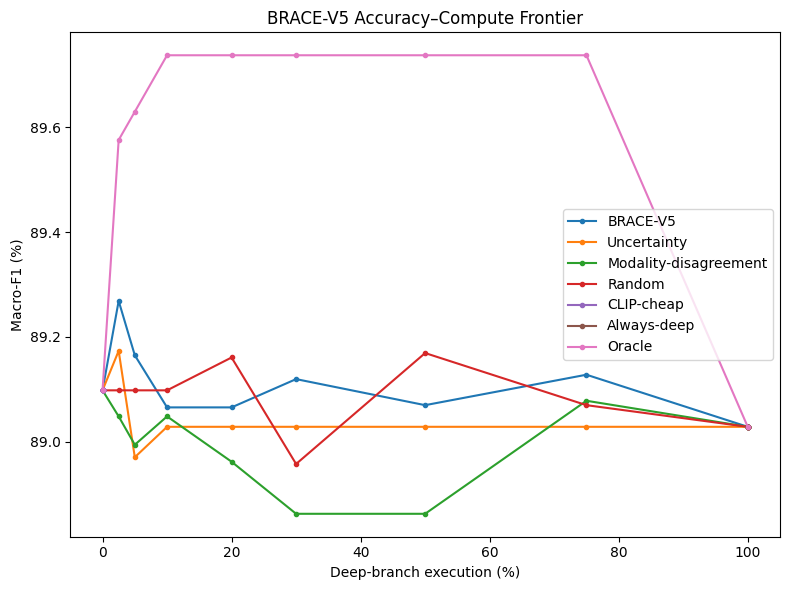

In [14]:

plot_methods=["BRACE-V5","Uncertainty","Modality-disagreement","Random","CLIP-cheap","Always-deep","Oracle"]
plt.figure(figsize=(8,6))
for method in plot_methods:
    g=summary[summary.method==method].sort_values("budget")
    plt.plot(g["deep_rate_mean"]*100,g["macro_f1_mean"]*100,marker=".",label=method)
plt.xlabel("Deep-branch execution (%)"); plt.ylabel("Macro-F1 (%)")
plt.title("BRACE-V5 Accuracy–Compute Frontier"); plt.legend(); plt.tight_layout()
plt.savefig(OUT_DIR/"v5_combined_pareto.png",dpi=180); plt.show()


## Paired bootstrap at matched budgets

Comparisons are paired on the same test samples and deep predictions. The Oracle is excluded from inferential claims because it uses test labels.


In [15]:

def paired_bootstrap_v5(run,budgets=BUDGETS,n_boot=N_BOOT):
    y=run["arrays"]["y"]; cheap=run["arrays"]["cheap"]; deep=run["arrays"]["deep"]
    brace=run["arrays"]["brace_score"]; unc=run["arrays"]["uncertainty_score"]; dis=run["arrays"]["disagreement_score"]
    out=[]
    for budget in budgets:
        pb=route_logits(cheap,deep,exact_k_route(brace,budget)).argmax(1)
        pu=route_logits(cheap,deep,exact_k_route(unc,budget)).argmax(1)
        pd_=route_logits(cheap,deep,exact_k_route(dis,budget)).argmax(1)
        pc=cheap.argmax(1)
        for name,other in [("CLIP-cheap",pc),("Uncertainty",pu),("Modality-disagreement",pd_)]:
            ci=bootstrap_diff(y,pb,other,lambda a,b:f1_score(a,b,average="macro"),
                              n_boot=n_boot,seed=900+int(budget*1000))
            out.append({"seed":run["seed"],"budget":budget,
                        "comparison":f"BRACE-V5 - {name}",
                        "ci_low":ci[0],"median":ci[1],"ci_high":ci[2]})
    return pd.DataFrame(out)
boot=pd.concat([paired_bootstrap_v5(r) for r in runs],ignore_index=True)
boot.to_csv(OUT_DIR/"v5_paired_bootstrap_95ci.csv",index=False)
boot_summary=boot.groupby(["budget","comparison"]).agg(
    ci_low=("ci_low","mean"),median=("median","mean"),ci_high=("ci_high","mean")
).reset_index()
boot_summary.to_csv(OUT_DIR/"v5_paired_bootstrap_summary.csv",index=False)
display(boot_summary)


,budget,comparison,ci_low,median,ci_high
0,0.000,BRACE-V5 - CLIP-cheap,0.000000,0.000000,0.000000
1,0.000,BRACE-V5 - Modality-disagreement,0.000000,0.000000,0.000000
2,0.000,BRACE-V5 - Uncertainty,0.000000,0.000000,0.000000
3,0.025,BRACE-V5 - CLIP-cheap,-0.001453,0.001695,0.004831
4,0.025,BRACE-V5 - Modality-disagreement,-0.000956,0.002193,0.005371
5,0.025,BRACE-V5 - Uncertainty,-0.002148,0.001001,0.004529
6,0.050,BRACE-V5 - CLIP-cheap,-0.002846,0.000670,0.004276
7,0.050,BRACE-V5 - Modality-disagreement,-0.001445,0.001738,0.005687
8,0.050,BRACE-V5 - Uncertainty,-0.001616,0.001882,0.005967
9,0.100,BRACE-V5 - CLIP-cheap,-0.004979,-0.000357,0.003505


## BRACE risk–benefit diagnostics

The diagnostic asks whether BRACE ranks samples that are simultaneously more likely to be wrong under the cheap model and more likely to benefit from the deep branch.


,fraction,mean_brace_score,mean_risk,mean_benefit_prob,mean_expected_gain,observed_cheap_error_rate,mean_actual_deep_gain,positive_actual_deep_gain_fraction
0,0.010,0.026861,0.815118,0.214578,0.183684,0.400000,0.028799,0.750000
1,0.025,0.021386,0.751951,0.252734,0.145123,0.360000,-0.005563,0.720000
2,0.050,0.017006,0.702541,0.281580,0.112008,0.260000,-0.012621,0.670000
3,0.100,0.012760,0.634348,0.328301,0.084882,0.215000,-0.034012,0.700000
4,0.200,0.008211,0.513789,0.428262,0.055616,0.155000,-0.023843,0.755000
5,0.300,0.005772,0.410138,0.525897,0.040742,0.118333,-0.020269,0.806667
6,0.500,0.003530,0.307374,0.628676,0.020447,0.084000,-0.015149,0.854000
7,1.000,0.001765,0.349244,0.584226,-0.024446,0.105000,-0.023625,0.826000


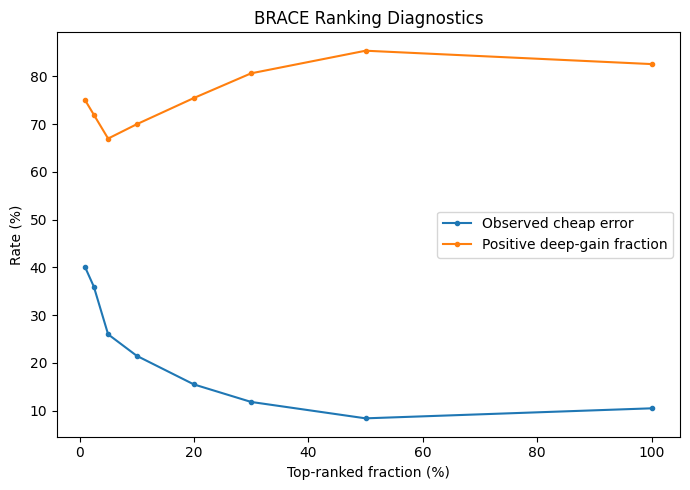

In [16]:

diag=brace_topk_all.groupby("fraction").agg(
    mean_brace_score=("mean_brace_score","mean"),mean_risk=("mean_risk","mean"),
    mean_benefit_prob=("mean_benefit_prob","mean"),mean_expected_gain=("mean_expected_gain","mean"),
    observed_cheap_error_rate=("observed_cheap_error_rate","mean"),
    mean_actual_deep_gain=("mean_actual_deep_gain","mean"),
    positive_actual_deep_gain_fraction=("positive_actual_deep_gain_fraction","mean")
).reset_index()
display(diag)
diag.to_csv(OUT_DIR/"v5_topk_brace_summary.csv",index=False)
plt.figure(figsize=(7,5))
plt.plot(diag["fraction"]*100,diag["observed_cheap_error_rate"]*100,marker=".",label="Observed cheap error")
plt.plot(diag["fraction"]*100,diag["positive_actual_deep_gain_fraction"]*100,marker=".",label="Positive deep-gain fraction")
plt.xlabel("Top-ranked fraction (%)"); plt.ylabel("Rate (%)")
plt.title("BRACE Ranking Diagnostics"); plt.legend(); plt.tight_layout()
plt.savefig(OUT_DIR/"v5_brace_ranking.png",dpi=180); plt.show()


## Resource accounting

Expected latency is `cheap_cost + deep_rate × deep_cost`. The same hardware measurements are used for all routing policies.


In [17]:

test_clip_ms=float(resource_components[(resource_components.split=="test")&(resource_components.component=="CLIP")].ms_per_sample.iloc[0])
test_vilt_ms=float(resource_components[(resource_components.split=="test")&(resource_components.component=="ViLT")].ms_per_sample.iloc[0])
resource_budget=[]
for budget in BUDGETS:
    effective=test_clip_ms+budget*test_vilt_ms
    resource_budget.append({"budget":budget,"clip_ms_per_sample":test_clip_ms,
        "vilt_ms_per_sample":test_vilt_ms,"effective_ms_per_sample":effective,
        "throughput_samples_per_sec":1000/effective,
        "latency_reduction_vs_always_deep":1-effective/(test_clip_ms+test_vilt_ms)})
resource_budget=pd.DataFrame(resource_budget)
resource_budget.to_csv(OUT_DIR/"v5_resource_budget_curve.csv",index=False)
results_compute=summary.merge(resource_budget,on="budget",how="left")
results_compute.to_csv(OUT_DIR/"v5_results_with_compute.csv",index=False)
display(results_compute[results_compute.method=="BRACE-V5"])


,budget,method,accuracy_mean,accuracy_sd,macro_f1_mean,macro_f1_sd,nll_mean,brier_mean,deep_rate_mean,clip_ms_per_sample,vilt_ms_per_sample,effective_ms_per_sample,throughput_samples_per_sec,latency_reduction_vs_always_deep
1,0.000,BRACE-V5,0.8950,NaN,0.890981,NaN,0.297781,0.165501,0.000,10.867286,21.564598,10.867286,92.019298,0.664920
8,0.025,BRACE-V5,0.8965,NaN,0.892687,NaN,0.297921,0.165109,0.025,10.867286,21.564598,11.406401,87.670075,0.648297
15,0.050,BRACE-V5,0.8955,NaN,0.891650,NaN,0.298413,0.165492,0.050,10.867286,21.564598,11.945516,83.713423,0.631674
22,0.100,BRACE-V5,0.8945,NaN,0.890656,NaN,0.301183,0.166329,0.100,10.867286,21.564598,13.023746,76.782827,0.598428
29,0.200,BRACE-V5,0.8945,NaN,0.890656,NaN,0.302550,0.166701,0.200,10.867286,21.564598,15.180205,65.875261,0.531936
36,0.300,BRACE-V5,0.8950,NaN,0.891195,NaN,0.303862,0.166378,0.300,10.867286,21.564598,17.336665,57.681220,0.465444
43,0.500,BRACE-V5,0.8945,NaN,0.890698,NaN,0.305356,0.166321,0.500,10.867286,21.564598,21.649585,46.190262,0.332460
50,0.750,BRACE-V5,0.8950,NaN,0.891279,NaN,0.311014,0.166684,0.750,10.867286,21.564598,27.040735,36.981244,0.166230
57,1.000,BRACE-V5,0.8940,NaN,0.890286,NaN,0.321407,0.169179,1.000,10.867286,21.564598,32.431884,30.833855,0.000000


In [18]:

# Representative BRACE confusion matrices, first seed.
rep=runs[0]; y=rep["arrays"]["y"]; cheap=rep["arrays"]["cheap"]; deep=rep["arrays"]["deep"]; score=rep["arrays"]["brace_score"]
for budget in [0.05,0.10,0.20,0.30,1.0]:
    pred=route_logits(cheap,deep,exact_k_route(score,budget)).argmax(1)
    pd.DataFrame(confusion_matrix(y,pred)).to_csv(
        OUT_DIR/f"v5_confusion_matrix_brace_{int(budget*100)}pct.csv",index=False)


In [19]:

def param_counts(model):
    return {"total":sum(p.numel() for p in model.parameters()),
            "trainable":sum(p.numel() for p in model.parameters() if p.requires_grad)}
rep=runs[0]
params=pd.DataFrame([
    {"component":"CLIP backbone",**param_counts(clip_model)},
    {"component":"ViLT backbone",**param_counts(vilt_model)},
    {"component":"Cheap head",**param_counts(rep["cheap"])},
    {"component":"Deep residual head",**param_counts(rep["deep"])}
])
params.to_csv(OUT_DIR/"v5_parameter_counts.csv",index=False); display(params)


,component,total,trainable
0,CLIP backbone,151277313,0
1,ViLT backbone,111595008,0
2,Cheap head,558466,558466
3,Deep residual head,1118466,1118466


## BRACE-V5 decision gate

A successful method run should show: (1) benefit prediction above chance, (2) BRACE ranking concentrates positive realized deep gain better than risk-only routing, (3) competitive matched-budget Macro-F1 against uncertainty and modality disagreement, (4) robustness across seeds, and (5) substantial measured compute savings.

If these conditions are not met, do not claim BRACE superiority; inspect the diagnostics before revising the method.


In [20]:

print("BRACE-V5 pilot gate")
gate=summary[summary.method.isin(["BRACE-V5","Uncertainty","Modality-disagreement"])]
for b in [0.05,0.10,0.20,0.30]:
    g=gate[gate.budget==b].set_index("method")
    if {"BRACE-V5","Uncertainty","Modality-disagreement"}.issubset(g.index):
        print(f"budget={b:.1%}: BRACE={g.loc['BRACE-V5','macro_f1_mean']:.6f}; "
              f"Uncertainty={g.loc['Uncertainty','macro_f1_mean']:.6f}; "
              f"Disagreement={g.loc['Modality-disagreement','macro_f1_mean']:.6f}")
display(calibration_all)


BRACE-V5 pilot gate
budget=5.0%: BRACE=0.891650; Uncertainty=0.889705; Disagreement=0.889943
budget=10.0%: BRACE=0.890656; Uncertainty=0.890286; Disagreement=0.890484
budget=20.0%: BRACE=0.890656; Uncertainty=0.890286; Disagreement=0.889619
budget=30.0%: BRACE=0.891195; Uncertainty=0.890286; Disagreement=0.888626


,model,roc_auc,brier,mean_predicted,observed_rate
0,risk,0.855214,0.161428,0.346887,0.098333
1,benefit,0.787005,0.193871,0.584868,0.824583


## V5 paper-ready outputs

- `v5_all_seed_budget_metrics.csv`
- `v5_manuscript_summary_mean_sd.csv`
- `v5_matched_budget_comparison.csv`
- `v5_paired_bootstrap_95ci.csv`
- `v5_paired_bootstrap_summary.csv`
- `v5_calibration.csv`
- `v5_brace_diagnostics.csv`
- `v5_topk_brace.csv`
- `v5_topk_brace_summary.csv`
- `v5_oracle_upper_bound.csv`
- `v5_resource_budget_curve.csv`
- `v5_results_with_compute.csv`
- `v5_parameter_counts.csv`
- `v5_combined_pareto.png`
- `v5_brace_ranking.png`

**First run: keep `RUN_MODE = "PILOT"`. Switch to PAPER only after the pilot completes without errors.**
